In [1]:
!pip install pandas matplotlib seaborn wordcloud


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from wordcloud import WordCloud

# Create images folder automatically
os.makedirs("images", exist_ok=True)

sns.set_theme(style="whitegrid")

In [3]:
df = pd.read_csv("data/twitter_sentiment.csv")
df.head()

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


In [4]:
df.columns
df.shape

(31962, 3)

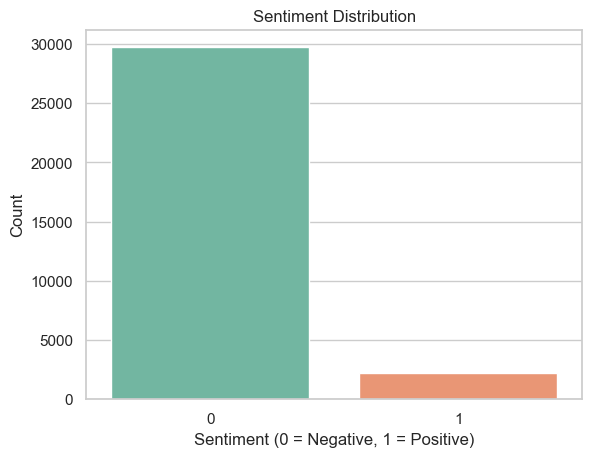

In [5]:
sns.countplot(data=df, x='label', hue='label', palette='Set2', legend=False)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment (0 = Negative, 1 = Positive)")
plt.ylabel("Count")

plt.savefig("images/sentiment_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

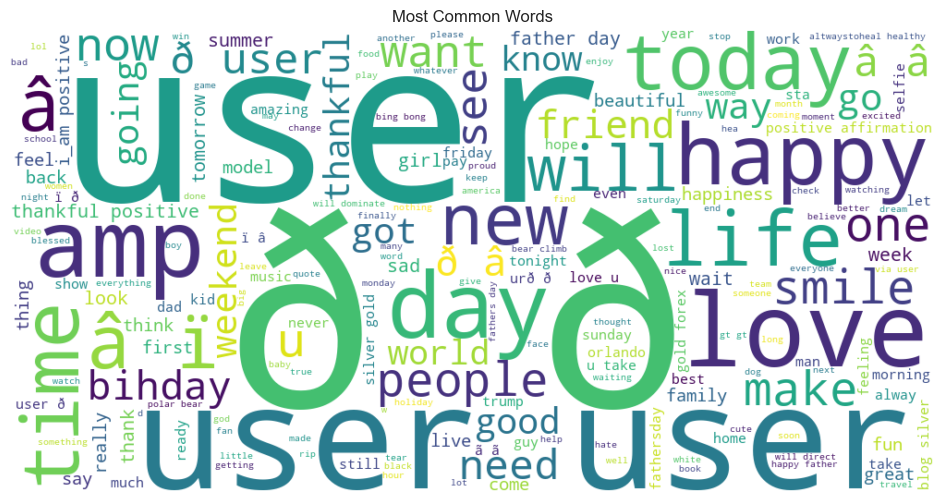

In [6]:
text = " ".join(df['tweet'].astype(str))

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    colormap='viridis'
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Most Common Words")

plt.savefig("images/wordcloud.png", dpi=300, bbox_inches='tight')
plt.show()

In [7]:
df.columns

Index(['id', 'label', 'tweet'], dtype='str')

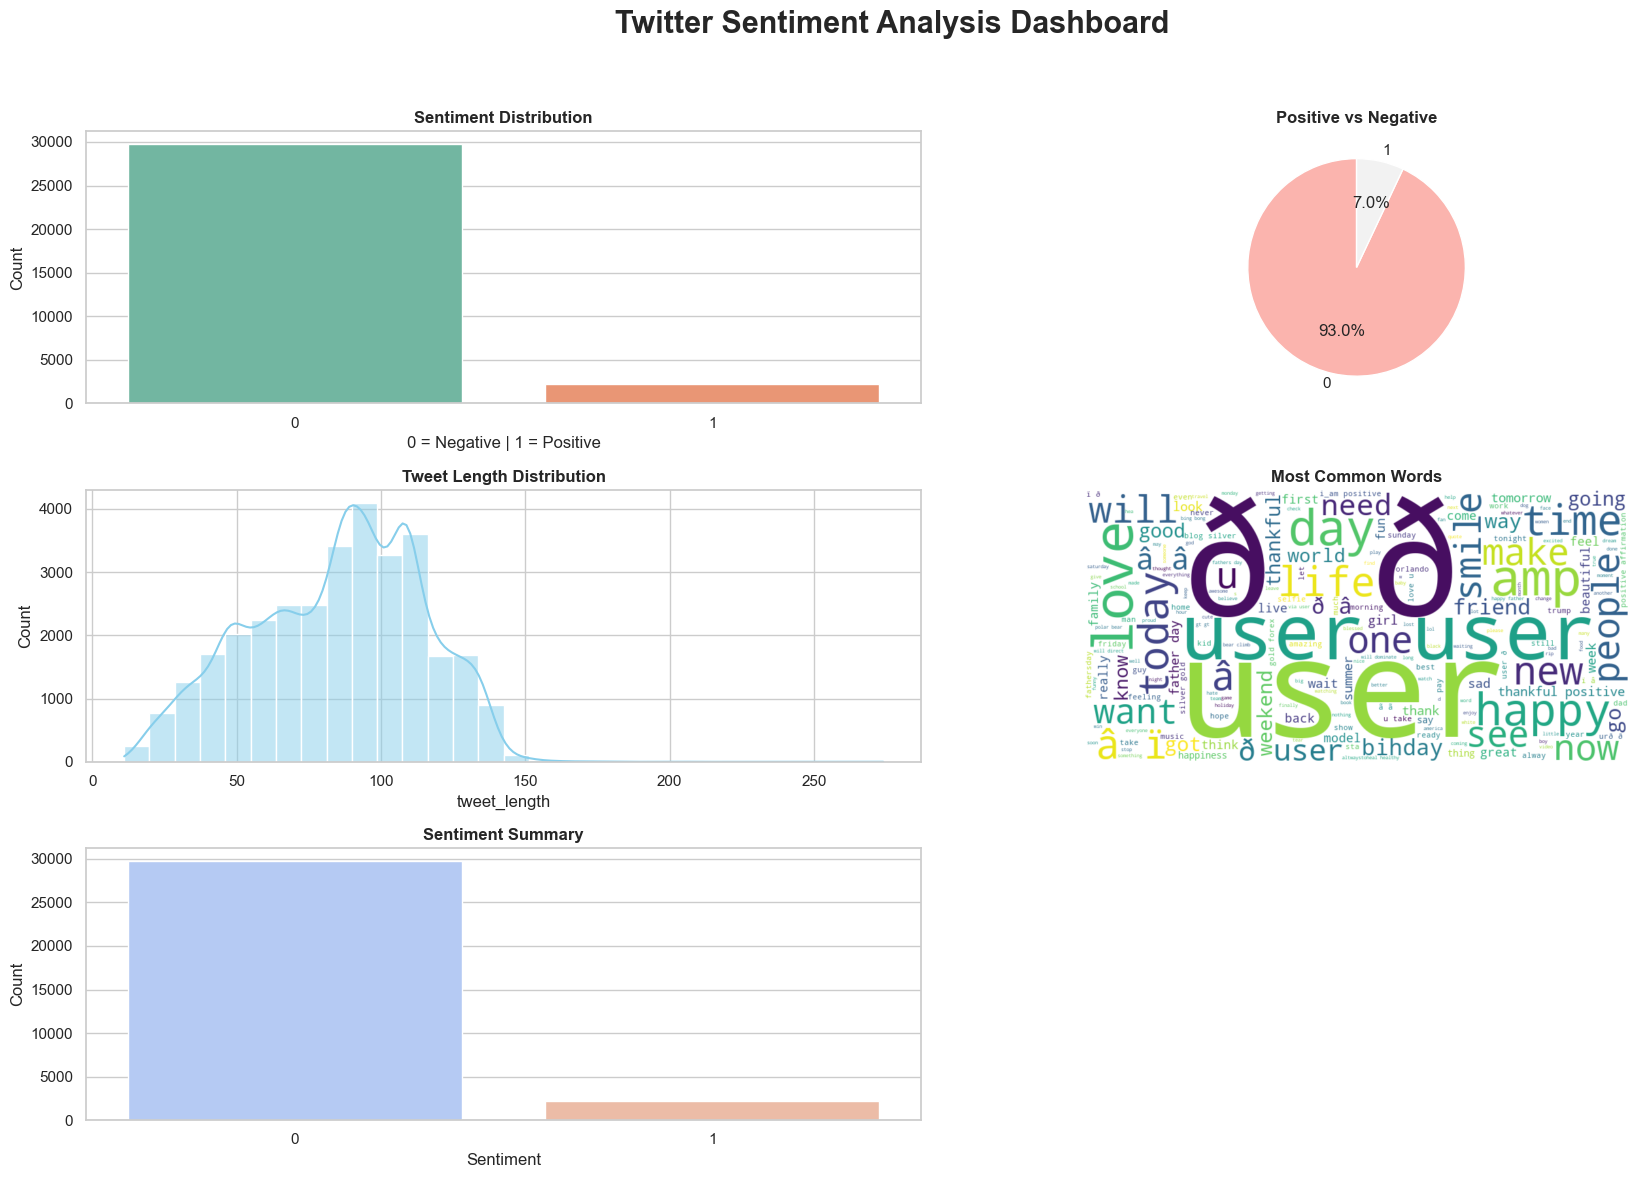

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

sns.set_theme(style="whitegrid")

# Add tweet length column
df["tweet_length"] = df["tweet"].astype(str).apply(len)

# Main figure
fig = plt.figure(figsize=(18,12))
fig.suptitle("Twitter Sentiment Analysis Dashboard", fontsize=22, fontweight='bold', y=0.98)

# -----------------------------
# 1. Sentiment Count
# -----------------------------
ax1 = plt.subplot(3,2,1)

sns.countplot(
    data=df,
    x='label',
    hue='label',
    palette='Set2',
    legend=False,
    ax=ax1
)

ax1.set_title("Sentiment Distribution", fontweight='bold')
ax1.set_xlabel("0 = Negative | 1 = Positive")
ax1.set_ylabel("Count")

# -----------------------------
# 2. Pie Chart
# -----------------------------
ax2 = plt.subplot(3,2,2)

df['label'].value_counts().plot.pie(
    autopct='%1.1f%%',
    startangle=90,
    cmap='Pastel1',
    ax=ax2
)

ax2.set_title("Positive vs Negative", fontweight='bold')
ax2.set_ylabel("")

# -----------------------------
# 3. Tweet Length Distribution
# -----------------------------
ax3 = plt.subplot(3,2,3)

sns.histplot(
    df["tweet_length"],
    bins=30,
    kde=True,
    color="skyblue",
    ax=ax3
)

ax3.set_title("Tweet Length Distribution", fontweight='bold')

# -----------------------------
# 4. WordCloud
# -----------------------------
ax4 = plt.subplot(3,2,4)

text = " ".join(df["tweet"].astype(str))

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='viridis'
).generate(text)

ax4.imshow(wordcloud, interpolation='bilinear')
ax4.axis("off")
ax4.set_title("Most Common Words", fontweight='bold')

# -----------------------------
# 5. Bar Chart Summary
# -----------------------------
ax5 = plt.subplot(3,2,5)

sentiment_counts = df['label'].value_counts()

sns.barplot(
    x=sentiment_counts.index,
    y=sentiment_counts.values,
    hue=sentiment_counts.index,
    palette='coolwarm',
    legend=False,
    ax=ax5
)

ax5.set_title("Sentiment Summary", fontweight='bold')
ax5.set_xlabel("Sentiment")
ax5.set_ylabel("Count")

# -----------------------------
# Remove Empty Plot
# -----------------------------
fig.delaxes(plt.subplot(3,2,6))

# Final layout
plt.tight_layout(rect=[0,0,1,0.95])

# Save image
plt.savefig("images/task4_dashboard.png", dpi=300, bbox_inches='tight')

plt.show()